In [1]:
import pandas as pd
from matplotlib import dates as mpl_dates
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
%config Completer.use_jedi = False

In [3]:
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [4]:
depthav_WT = pd.read_csv('teste_malha_depthav_WT_compare.csv')
depthav_WT['time'] = pd.to_datetime(depthav_WT['time'], format = '%d/%m/%Y %H:%M') # transforms datatype to datetime
depthav_WT.rename(columns = {'measurements':'Measured'}, inplace = True)
depthav_WT

,time,6x6m,8x8m,10x10m,Measured
0,2022-09-09 00:00:00,25.235526,25.235526,25.235526,25.238937
1,2022-09-09 06:00:00,25.058902,25.058506,25.064069,25.047125
2,2022-09-09 12:00:00,25.042494,25.039124,25.001895,25.049995
3,2022-09-09 18:00:00,25.017814,25.017146,24.938902,25.049921
4,2022-09-10 00:00:00,24.827834,24.827293,24.754525,24.861452
...,...,...,...,...,...
2208,2024-03-14 00:00:00,8.254488,8.226200,4.116287,8.962566
2209,2024-03-14 06:00:00,8.658746,8.627665,4.374604,9.412135
2210,2024-03-14 12:00:00,8.749619,8.718707,4.403653,9.428258
2211,2024-03-14 18:00:00,8.685521,8.650720,4.347131,9.334621


In [5]:
# Calculates metrics for each run - depth averaged
r2_list = []
RMSE_list = []
bias_list = []

for scen in range(len(depthav_WT.columns[1:-1])):
    temp = depthav_WT[depthav_WT.columns[[-1,scen+1]]].copy()
       
    n = len(temp)

    x = temp[temp.columns[0]]
    y = temp[temp.columns[1]]

    mask = ~np.isnan(x) & ~np.isnan(y)

    # metrics
    r2 = ((np.corrcoef(np.array(x)[mask], np.array(y)[mask])[0,1]) ** 2)
    temp['sq_error'] = ((temp[temp.columns[0]] - temp[temp.columns[1]]) ** 2)
    RMSE = (((1/n) * (temp['sq_error'].sum()) ) ** 0.5)
    bias = (((temp[temp.columns[1]] - temp[temp.columns[0]]).sum()) / n)
    
    r2_list.append(r2)
    RMSE_list.append(RMSE)
    bias_list.append(bias)
    
    print('r² (' + temp.columns[1] + '):', r2)
    print('RMSE (' + temp.columns[1] + '):', RMSE)
    print('bias (' + temp.columns[1] + '):', bias)

print('')
print('r² surface:', r2_list)
print('RMSE surface:', RMSE_list)
print('bias surface:', bias_list)

r² (6x6m): 0.9985653681873327
RMSE (6x6m): 0.5557252798633138
bias (6x6m): -0.47410474186669677
r² (8x8m): 0.9986836673492953
RMSE (8x8m): 0.5566507188125224
bias (8x8m): -0.48061619362358793
r² (10x10m): 0.9568275502377347
RMSE (10x10m): 3.9017186869121674
bias (10x10m): -3.542875288502937

r² surface: [np.float64(0.9985653681873327), np.float64(0.9986836673492953), np.float64(0.9568275502377347)]
RMSE surface: [np.float64(0.5557252798633138), np.float64(0.5566507188125224), np.float64(3.9017186869121674)]
bias surface: [np.float64(-0.47410474186669677), np.float64(-0.48061619362358793), np.float64(-3.542875288502937)]


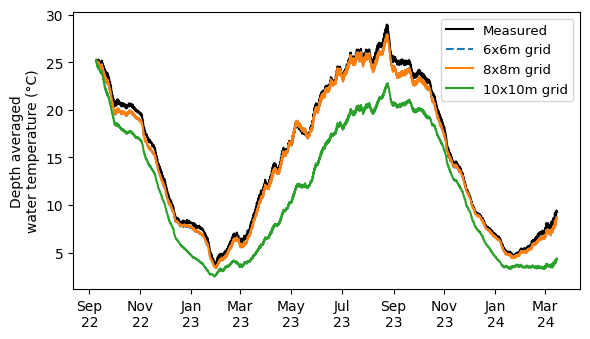

In [11]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [6,3.5], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

ax.plot(depthav_WT.time,
        depthav_WT[depthav_WT.columns[-1]], 
        color='k', 
        linestyle='-', label = 'Measured')

ax.plot(depthav_WT.time,
        depthav_WT[depthav_WT.columns[1]], 
        color=pal.as_hex()[0], 
        linestyle='--', label = '6x6m grid')

ax.plot(depthav_WT.time,
        depthav_WT[depthav_WT.columns[2]], 
        color=pal.as_hex()[1], 
        linestyle='-', label = '8x8m grid')

ax.plot(depthav_WT.time,
        depthav_WT[depthav_WT.columns[3]], 
        color=pal.as_hex()[2], 
        linestyle='-', label = '10x10m grid')

ax.set_xlim(ax.get_xlim()[0], ax.get_xlim()[-1])
ax.legend(loc = 'upper right', fontsize = 9.5)
ax.grid(False)

# Format date labels
myFmt = mdates.DateFormatter('%b\n%y') # date format with month in string!
ax.xaxis.set_major_formatter(myFmt)

ax.yaxis.set_label_text(u'Depth averaged\nwater temperature (°C)')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('grid_resol_tests_depthav_WT.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

In [44]:
depthav_WT.head(3)

,time,6x6m,8x8m,10x10m,measurements
0,2022-09-09 00:00:00,25.235526,25.235526,25.235526,25.238937
1,2022-09-09 06:00:00,25.058902,25.058506,25.064069,25.047125
2,2022-09-09 12:00:00,25.042494,25.039124,25.001895,25.049995


In [66]:
## DATAFRAME FOR CREATING BOXPLOTS
ndepths = 9 # number of model output time series per depth

for scen in range(4):
    temp_df = depthav_WT[depthav_WT.columns[[0,scen+1]]].copy()
    
    if scen == 0:
        depthav_WT_boxplot = temp_df.copy()
        depthav_WT_boxplot.set_index('time', inplace = True)
        depthav_WT_boxplot.rename(columns = {depthav_WT_boxplot.columns[0]:'WT_degC'}, inplace = True)
        depthav_WT_boxplot['scenario'] = depthav_WT.columns[scen+1]
        
    else:
        temp_df.set_index('time', inplace = True)
        temp_df.rename(columns = {temp_df.columns[0]:'WT_degC'}, inplace = True)
        temp_df['scenario'] = depthav_WT.columns[scen+1]
        depthav_WT_boxplot = pd.concat([depthav_WT_boxplot, temp_df])
    
# # Creates columns with month
# bp_WT_comp_depths['month'] = bp_WT_comp_depths.index.month
# bp_WT_comp_depths['year'] = bp_WT_comp_depths.index.year
# bp_WT_comp_depths['year'] = bp_WT_comp_depths['year'].apply(lambda x: str(x)[2:])
# bp_WT_comp_depths['month_str'] = ((bp_WT_comp_depths['month'].apply(lambda x: calendar.month_abbr[x])) + 
#                                   (bp_WT_comp_depths['year']))
# bp_WT_comp_depths.reset_index(drop = True, inplace = True)
depthav_WT_boxplot

,WT_degC,scenario
time,,
2022-09-09 00:00:00,25.235526,6x6m
2022-09-09 06:00:00,25.058902,6x6m
2022-09-09 12:00:00,25.042494,6x6m
2022-09-09 18:00:00,25.017814,6x6m
2022-09-10 00:00:00,24.827834,6x6m
...,...,...
2024-03-14 00:00:00,8.962566,Measured
2024-03-14 06:00:00,9.412135,Measured
2024-03-14 12:00:00,9.428258,Measured


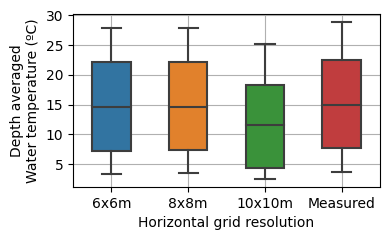

In [68]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [4,2.5], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

sns.boxplot(x = "scenario", y = "WT_degC", 
            data = depthav_WT_boxplot,
            width = 0.5,boxprops = {'zorder': 2}, palette = pal[0:8], ax = ax)

ax.grid(True)

# ax.legend(title = "FPV coverage scenario", ncol = 2, fontsize = 10, 
#                frameon = True, columnspacing = 1, loc = 'lower left')

# ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
#                frameon = True, columnspacing = 1, bbox_to_anchor=(1, 1.04))

ax.yaxis.set_label_text(u'Depth averaged\nWater temperature (ºC)', fontsize = 10)
ax.xaxis.set_label_text(u'Horizontal grid resolution', fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig('boxplot_grid_resolution_tests.jpeg', dpi=300, bbox_inches='tight')

plt.show();